In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [3]:
df = pd.read_csv("Iris.csv")

In [4]:
print("First 5 Rows of Dataset:")
print(df.head())

First 5 Rows of Dataset:
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


In [5]:
X = df.drop('variety', axis=1)
y = df['variety']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = GaussianNB()
model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [9]:
y_pred = model.predict(X_test_scaled)

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)

In [11]:
print("\nConfusion Matrix:")
print(cm_df)


Confusion Matrix:
            Setosa  Versicolor  Virginica
Setosa          10           0          0
Versicolor       0           9          0
Virginica        0           0         11


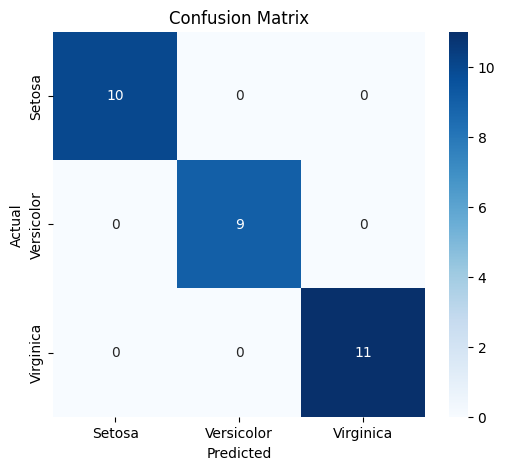

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
print("\nClass-wise TP, FP, TN, FN:")
for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(f"\nClass: {label}")
    print(f"True Positives (TP): {TP}")
    print(f"False Positives (FP): {FP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Negatives (FN): {FN}")


Class-wise TP, FP, TN, FN:

Class: Setosa
True Positives (TP): 10
False Positives (FP): 0
True Negatives (TN): 20
False Negatives (FN): 0

Class: Versicolor
True Positives (TP): 9
False Positives (FP): 0
True Negatives (TN): 21
False Negatives (FN): 0

Class: Virginica
True Positives (TP): 11
False Positives (FP): 0
True Negatives (TN): 19
False Negatives (FN): 0


In [14]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("\nOverall Model Evaluation:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


Overall Model Evaluation:
Accuracy: 1.00
Error Rate: 0.00
Precision: 1.00
Recall: 1.00
